In [2]:
import numpy as np 
from sklearn.datasets import load_iris 
from sklearn.linear_model import Perceptron

In [3]:
iris = load_iris(as_frame=True)
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = (iris.target == 0) # Iris setosa

In [4]:
per_clf = Perceptron(random_state=42) 
per_clf.fit(X,y)

,penalty,None
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,eta0,1.0
,n_jobs,None
,random_state,42


In [5]:
X_new = [[2,0.5],[3,1]]
y_pred = per_clf.predict(X_new)

In [6]:
def calc_xor(inputs: np.matrix, weights: np.matrix, bias: float) -> np.matrix:
    linear_output = np.vdot(weights.T, inputs).item() + bias
    if linear_output < 0:
        return 0
    else:
        return 1

In [7]:
inputs = [np.matrix([0,0]), np.matrix([1,1]), np.matrix([0,1]), np.matrix([1,0])]
for matrix in inputs:
    layer_1_weights = np.matrix([1,1])
    layer_2_weights = np.matrix([-1,1])
    output_1, output_2 = calc_xor(matrix, layer_1_weights, -3/2), calc_xor(matrix, layer_1_weights, -1/2)
    final_input = np.matrix([output_1, output_2])
    print(calc_xor(final_input, layer_2_weights, -1/2))

0
0
0
0


In [8]:
print(np.vdot(np.matrix([0,0]).T, np.matrix([1,1])).item())

0


In [9]:
x_range = np.arange(-4,5)
sigmoid = [1 / (1 + np.exp(-x)) for x in x_range]
heaviside = np.piecewise(x_range, [x_range < 0, x_range >= 0], [0,1])
hyp_tang = np.tanh(x_range)
relu = [np.fmax(0,x) for x in x_range]
functions = {"Sigmoid": sigmoid, "Heaveside": heaviside, "Tanh": hyp_tang, "ReLU": relu}

C:\Users\Logan\AppData\Local\Temp\ipykernel_44276\278713337.py:5: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o-" (-> marker='o'). The keyword argument will take precedence.
  plt.plot(x_range, heaviside, 'o-', marker="", label='Heaveside')
C:\Users\Logan\AppData\Local\Temp\ipykernel_44276\278713337.py:7: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "p-." (-> marker='p'). The keyword argument will take precedence.
  plt.plot(x_range, relu, 'p-.',marker="", label='ReLU')


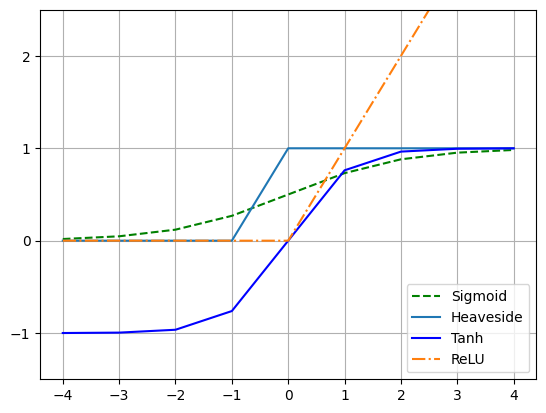

In [12]:
import matplotlib.pyplot as plt
from scipy import interpolate

plt.plot(x_range,sigmoid,'g--', marker="", label='Sigmoid')
plt.plot(x_range, heaviside, 'o-', marker="", label='Heaveside')
plt.plot(x_range, hyp_tang, 'b-', marker="", label='Tanh')
plt.plot(x_range, relu, 'p-.',marker="", label='ReLU')
plt.ylim([-1.5,2.5])
plt.yticks(np.arange(-1,3))
plt.grid()
plt.legend(loc='lower right')
plt.show()

In [13]:
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [14]:
housing = fetch_california_housing()

In [15]:
X_train_full, X_test, y_train_full, y_test = train_test_split(housing.data, housing.target, random_state=42)

In [16]:
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, random_state=42)

In [17]:
mlp_reg = MLPRegressor(hidden_layer_sizes=[50,50,50], random_state=42) 
pipeline = make_pipeline(StandardScaler(), mlp_reg)

In [18]:
pipeline.fit(X_train, y_train)

,steps,"[('standardscaler', ...), ('mlpregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,loss,'squared_error'
,hidden_layer_sizes,"[50, 50, ...]"
,activation,'relu'
,solver,'adam'


In [19]:
y_pred = pipeline.predict(X_val)

In [20]:
rmse = root_mean_squared_error(y_pred, y_val)

In [21]:
rmse

0.505332665796845